# Steel Shear Link

This example compares the shear response of the `MultiaxialFiber` section with the `NDFiber` section of OpenSees. 

## Modeling

### Material

Begin by defining a {py:class}`xara.MultiaxialMaterial`.

In [2]:
#
# Hjelmstad's shear link #4
#
import xara
import veux

import xara.units.iks as units
from xara.helpers import find_node


verbose = False
Save = False


Fy = 35.0*units.ksi
E  = 30e3*units.ksi
G  = 12e3*units.ksi

Aspect = 1.5

material = xara.MultiaxialMaterial(
    type="NonlinearJ2", # "J2BeamThread", # 
    E =  E,
    G =  G,
    Fy = Fy,
    Hiso = 0.002*E,
    Hkin = 0.002*E
)

Next, a `shape` object is created. This will be used to generate fibers with appropriate shear properties, like the shear correction factor $\kappa$ used by `NDFiber` and the warping shapes $\varphi$ used by `MultiaxialFiber`.

In [3]:

from xsection.library import from_aisc
shape = from_aisc("W18x40",
                units=units,
                mesh_scale=1,
                material=material,
                fillet=True,
                mesh_type="T3",
                mesher="gmsh")


L = shape.d*Aspect

Finally, the `Section` objects are created with the two formulations of interest.

In [4]:

sections = [
    xara.Section("NDFiber", shape),
    xara.Section("MultiaxialFiber", shape)
]

### Model

In [5]:
def create_model(length, section, material):
    model = xara.Model(ndm=3, ndf=6)
    
    model.node(1, (     0, 0, 0))
    model.node(2, (length, 0, 0))

    model.fix(1, (1,1,1,  1,1,1))
    model.fix(2, (1,1,0,  0,1,1))

    model.material(material)
    model.section(section)

    model.geomTransf("Linear",  1, (0, 0, 1))
    model.element("ForceFrame", 1, (1,2), 
                  section=section, shear=1, transform=1)

    return model

## Analysis

In [6]:
def analyze(model, ctrl_node, plots=(), verbose=False):

    if verbose:
        progress = lambda x: x
    else:
        from tqdm import tqdm as progress

    # Loading
    step = 100
    a = 0.1


    series = xara.TimeSeries(values=[0,  0.05,   0.5, -0.5, -0.05],
                             time=  [0,   a,   1,    4,   5 ])

    # Create the control load
    ctrl = xara.NodalValue(model, node=ctrl_node, dof=3, value=1.0)
    pattern = xara.StaticPattern(ctrl, series=series)

    model.pattern(pattern)

    analysis = xara.StaticAnalysis(model, 
                                   integrator=("LoadControl", 1/step),
                                   system="BandGeneral", 
                                   constraints="Transformation", 
                                   test=("Energy", 1e-18, 20, 2 if verbose else 0))

    for _ in progress(range(step*5)):
        if model.state.time >= 5.0:
            break

        if analysis.analyze(1) != 0:
            print(f"Failed at time = {model.state.time}")
            return

        for plot in plots:
            plot.update(model)


Running NDFiber


100%|██████████| 500/500 [00:01<00:00, 267.80it/s]


Running MultiaxialFiber


100%|██████████| 500/500 [00:03<00:00, 155.71it/s]


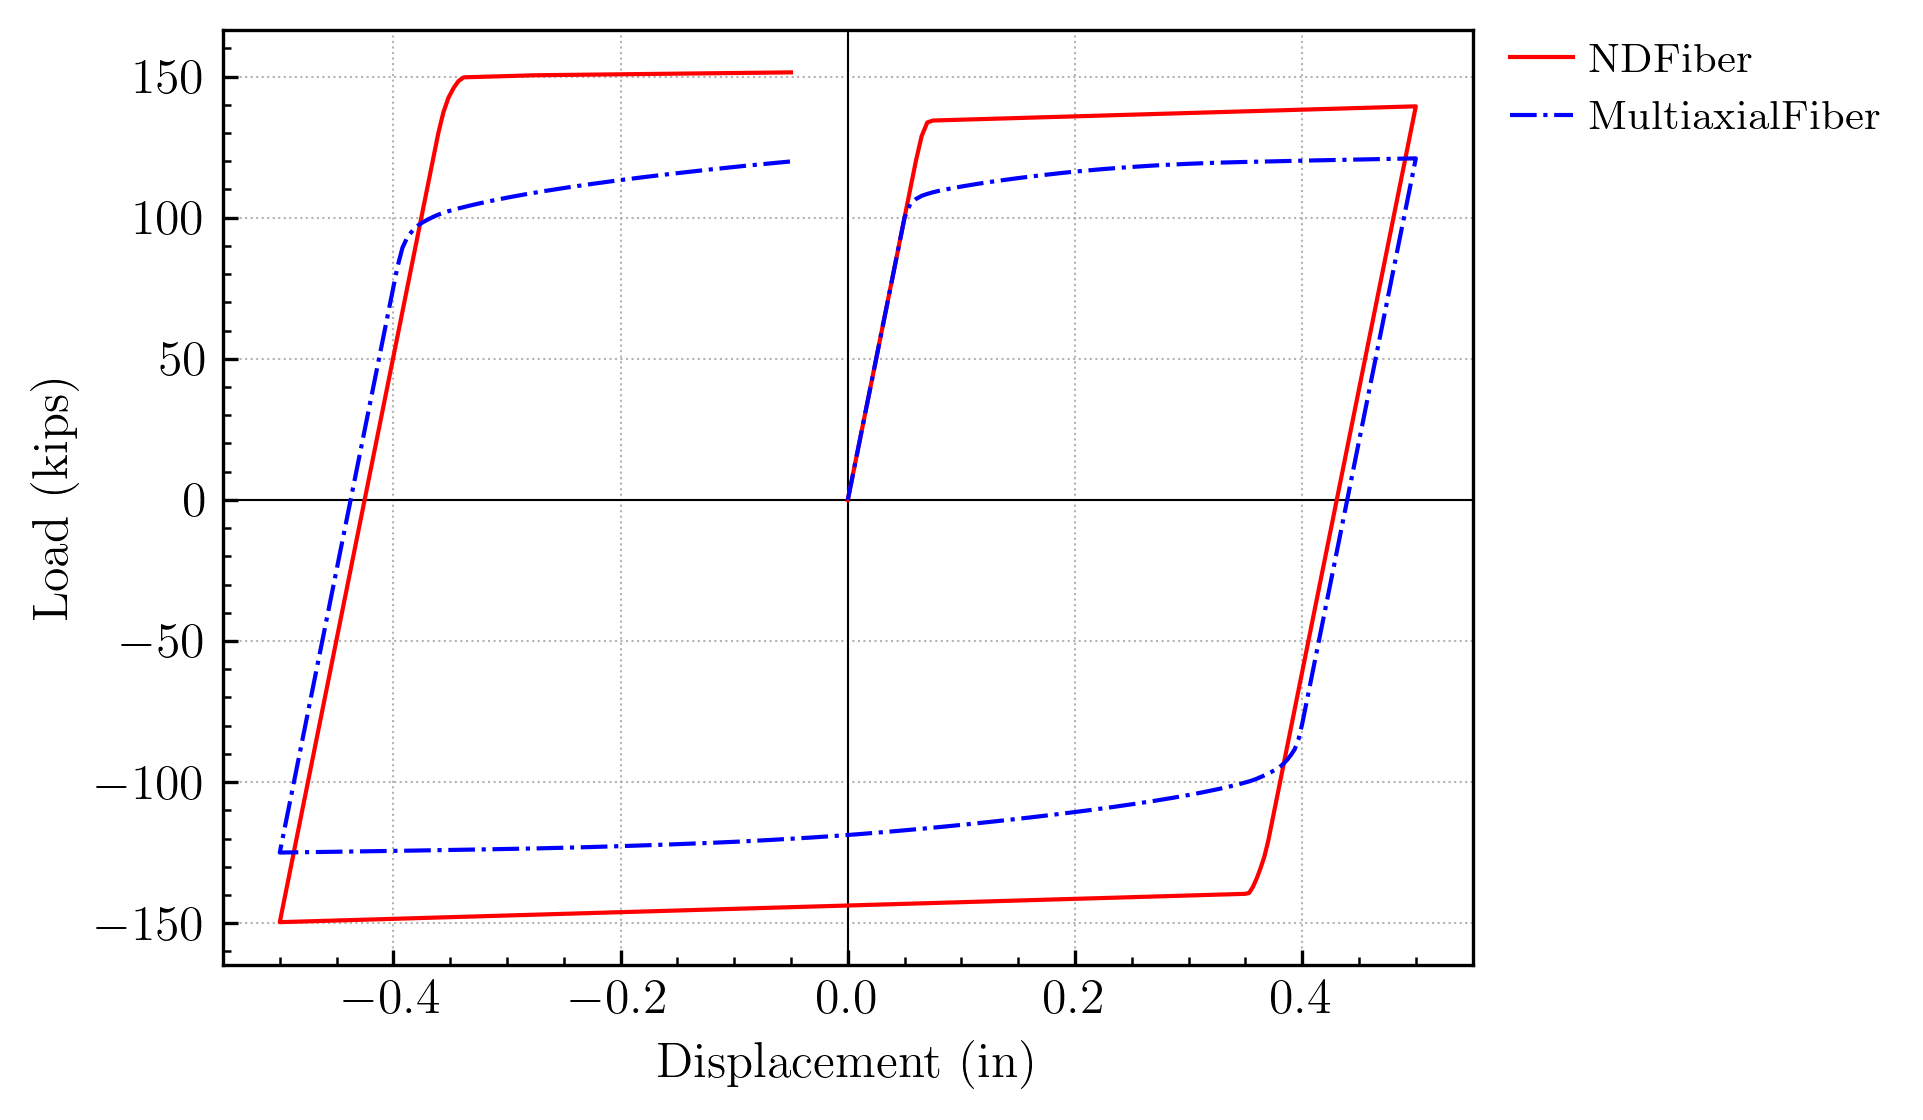

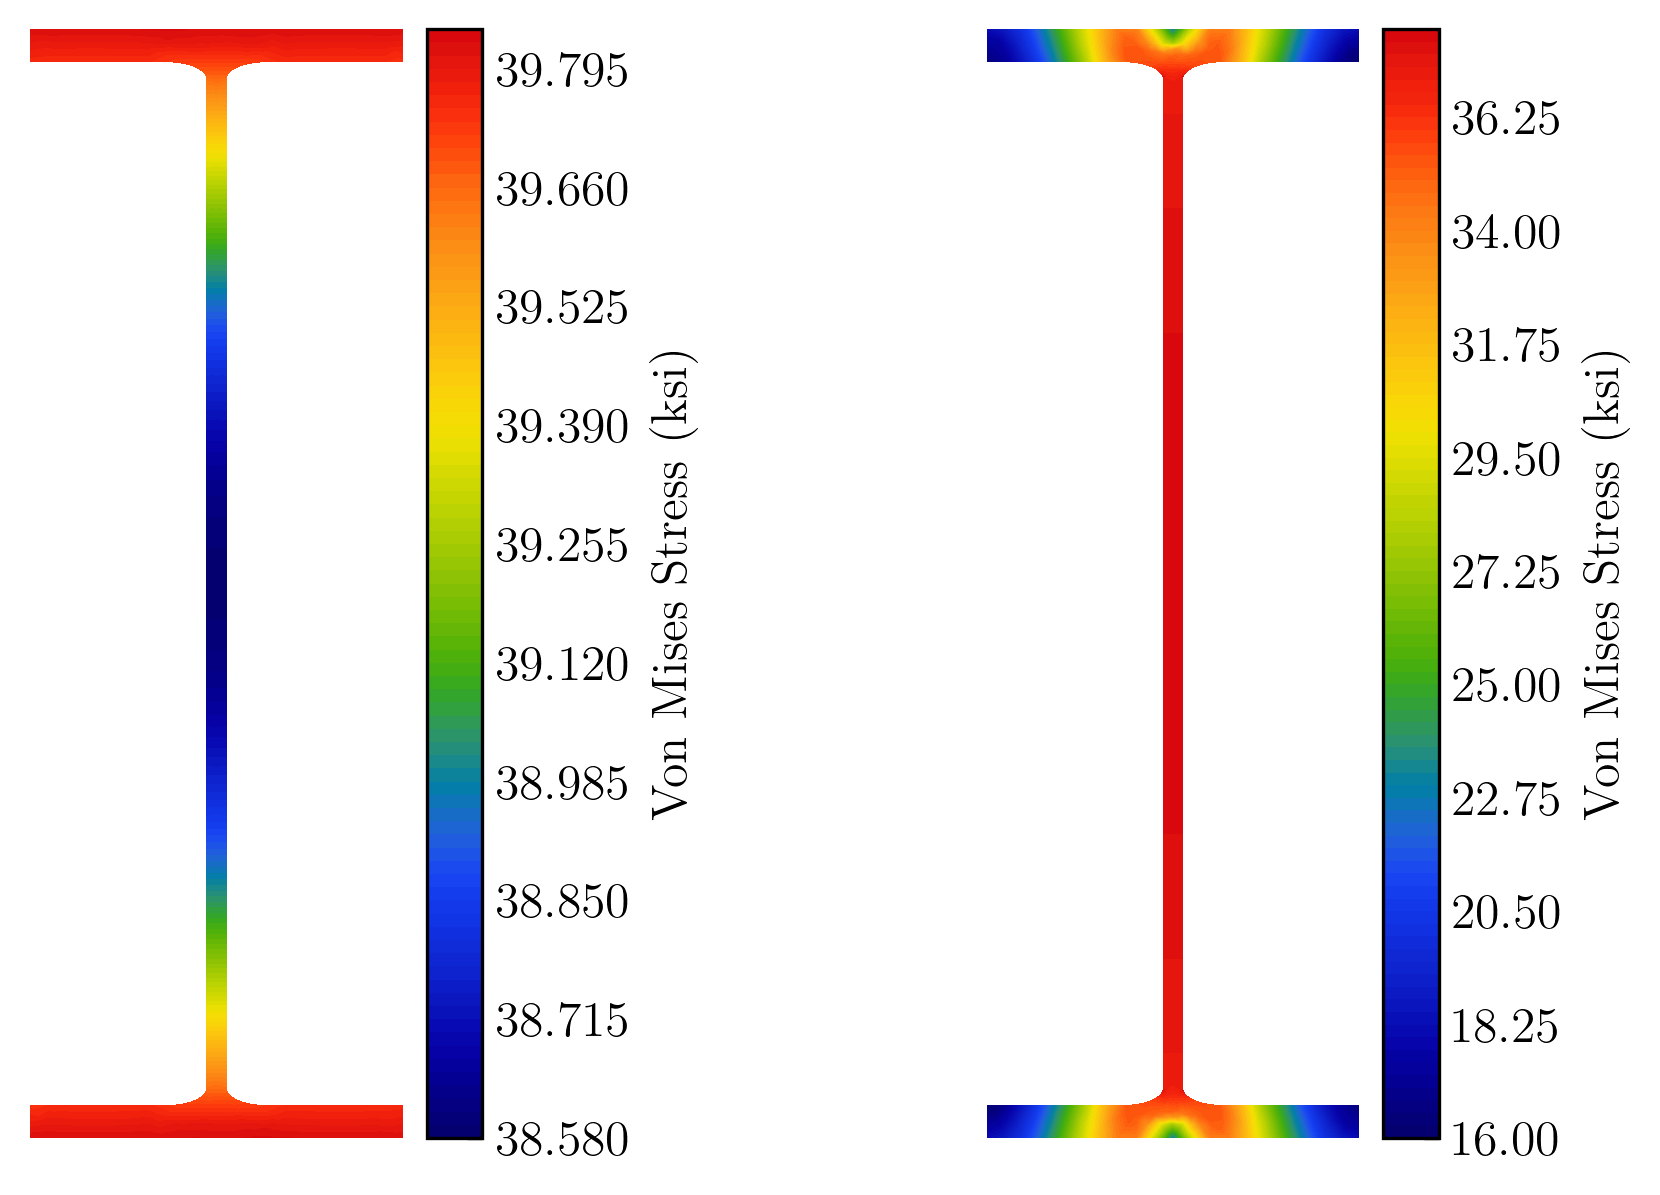

In [7]:
import matplotlib.pyplot as plt
from post import PlotResponse
from xara.post import FiberStress

##
plot_1 = PlotResponse()


_,plot_stress = plt.subplots(1,2)
plot_stress[0].figure.subplots_adjust(wspace=0.8)

##

for i,section in enumerate(sections):


    print(f"Running {section.type}")

    model = create_model(L, section, material)


    plot_1.reset(model,
                node=find_node(model, x=L), 
                dof=3,
                label=section.type
    )


    analyze(model,
            find_node(model, x=L),
            verbose=verbose,
            plots=[plot_1]
    )

    plot_1.draw()

    # Plot stress distribution at the end of the analysis
    artist = veux.ShapeArtist(shape, ax=plot_stress[i])
    artist.draw_surfaces(
        field=FiberStress(model, shape, section=1, stress="svm", element=1),
        cbar_label="Von Mises Stress (ksi)",
    )


plot_1.finish()
